# Поиск наилучшего узла

Узлов: 5514 Ребер: 12199
Расчет узлов
426923808 7.36


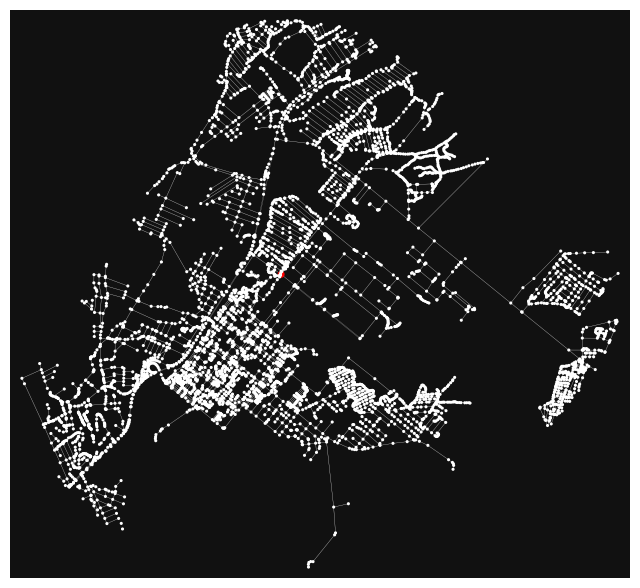

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [18]:
import numpy as np
import networkx as nx
import osmnx as ox

from genesis.algorithms import Graphs
from genesis.metrics import calc_node_metric, cover_index
from genesis.swiss_knife import msfpl, ssfpl


G = ox.load_graphml('tests/data/test_rng.ml')
print("Узлов:", G.number_of_nodes(), "Ребер:",  G.number_of_edges())

print('Расчет узлов')
best_node, best_val = Graphs.get_best_node_full(G, 
                          path_function=msfpl,
                          metric_function=np.mean
                          )
print(best_node, best_val)

nc = ['r' if nd==best_node else 'w' for nd in G.nodes()]
ns = [25 if nd==best_node else 5 for nd in G.nodes()]
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

## Расчет времени прибытия в каждый из узлов

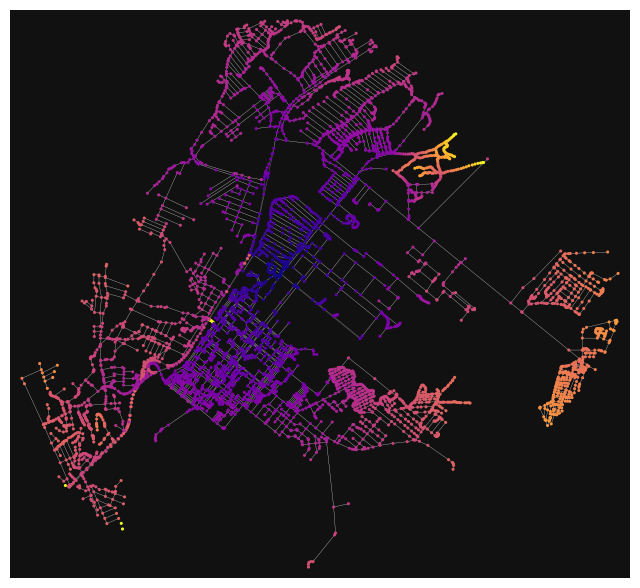

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [15]:
lens = ssfpl(G, best_node, weight = 'travel_time')
mval = max(lens.values())
lens_full = {node:lens[node] if node in lens else mval for node in G.nodes()}

nx.set_node_attributes(G, lens_full, 'route_time')
nc = ox.plot.get_node_colors_by_attr(G, attr="route_time", cmap="plasma")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=5)

## Расчет метрик во всех узлах

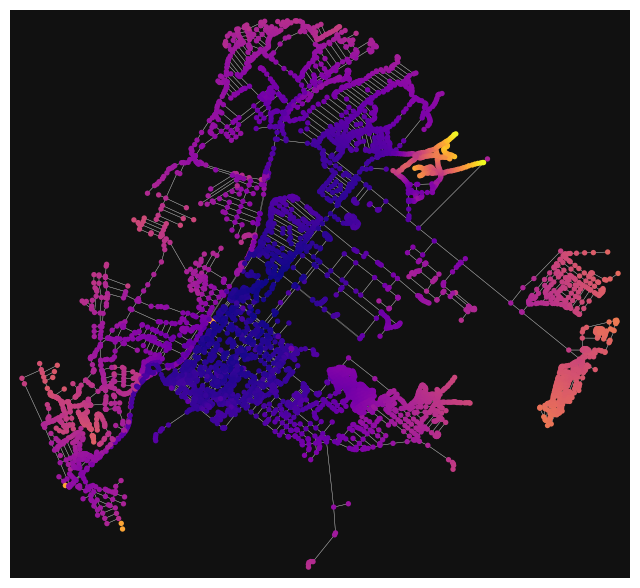

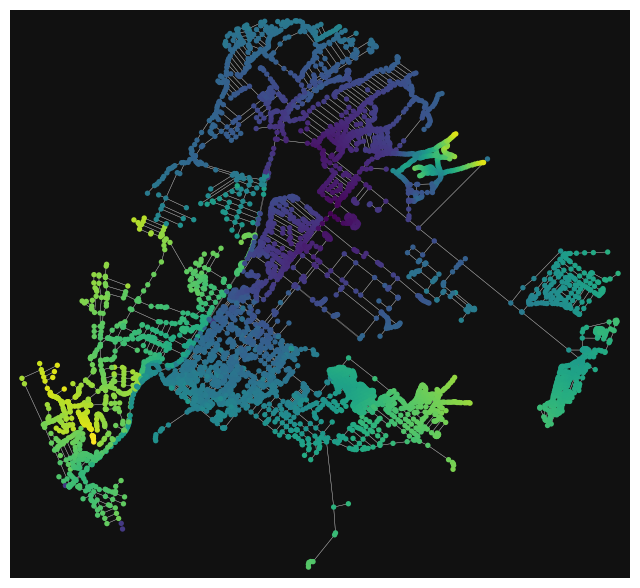

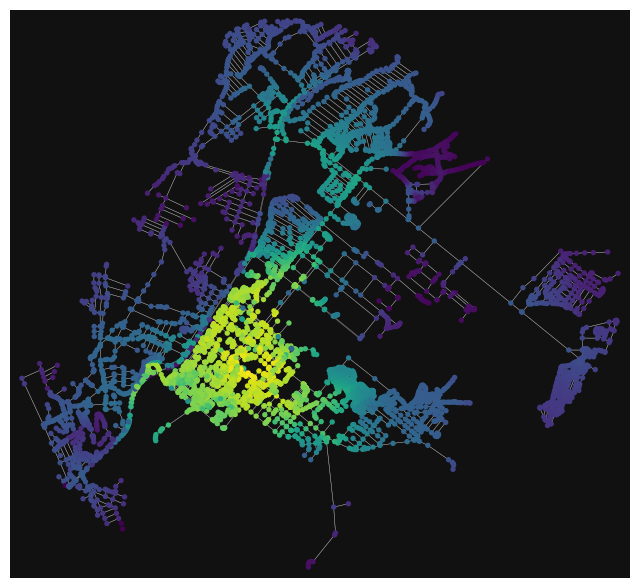

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [4]:
route_time_mean = {}
route_time_max = {}
nodes_ip5 = {}

i=0
for node in G.nodes():
    print(f'{i}/{G.number_of_nodes():<5}', end='\r')
    route_time_mean[node] = calc_node_metric(G, 
                    node, 
                    path_function=msfpl, 
                    metric_function=np.mean,
                    err_val=20)
    route_time_max[node] = calc_node_metric(G, 
                    node, 
                    path_function=msfpl, 
                    metric_function=np.max,
                    err_val=20)
    nodes_ip5[node] = calc_node_metric(G, 
                    node, 
                    path_function=msfpl, 
                    metric_function=cover_index(ip_val=5),
                    err_val=0)    
    i+=1

# Установка значений
nx.set_node_attributes(G, route_time_mean, 'route_time_mean')
nx.set_node_attributes(G, route_time_max, 'route_time_max')
nx.set_node_attributes(G, nodes_ip5, 'nodes_ip5')

# Печать карты со средними значениями
nc = ox.plot.get_node_colors_by_attr(G, attr="route_time_mean", cmap="plasma")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.3)

# Печать карты с максимальными значениями
nc = ox.plot.get_node_colors_by_attr(G, attr="route_time_max", cmap="viridis")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.3)

# Печать карты с значениями ИП-5
nc = ox.plot.get_node_colors_by_attr(G, attr="nodes_ip5", cmap="viridis")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.3)

## Поиск наилучшего узла из некоторого множества

In [9]:
nodes = list(G.nodes())
nodes_set = [nodes[50], nodes[200], nodes[500], nodes[1000], nodes[1500], nodes[3000], nodes[4000]]
print(nodes_set)
best_node, best_val = Graphs.get_best_node_full(G, 
                          path_function=msfpl,
                          metric_function=np.mean,
                          possible_nodes=nodes_set
                          )
print("лучший узел", best_node, best_val)

print('метрики для каждого из узлов:')
for node in nodes_set:
    m = calc_node_metric(G, 
                     node, 
                     path_function=msfpl,
                     metric_function=np.mean)
    print(node, m)

[426923800, 1526100295, 1555148534, 2034401706, 2034402276, 2760591335, 4901942432]
лучший узел 1555148534 7.82
метрики для каждого из узлов:
426923800 8.88
1526100295 13.98
1555148534 7.82
2034401706 8.45
2034402276 11.34
2760591335 10.6
4901942432 11.52


## Расчет лучшего узла алгоритмом стока

In [1]:
import numpy as np
import networkx as nx
import osmnx as ox

from genesis.algorithms import Graphs
from genesis.metrics import calc_node_metric, cover_index
from genesis.swiss_knife import msfpl, ssfpl

import random
import logging as lg


G = ox.load_graphml('tests/data/test_rng.ml')
print("Узлов:", G.number_of_nodes(), "Ребер:",  G.number_of_edges())

Узлов: 5514 Ребер: 12199


In [2]:
# lg.basicConfig(level=lg.DEBUG)
# lg.basicConfig(level=lg.ERROR)
best_node, best_val, route = Graphs.get_best_node_drain(G, 
                          path_function=msfpl,
                          metric_function=np.mean,
                          )
# lg.basicConfig(level=lg.ERROR)

print(best_node, best_val)
# nc = ['r' if nd in route else 'w' for nd in G.nodes()]
# ns = [25 if nd in route else 5 for nd in G.nodes()]
# ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

2034401724 8.45


In [3]:
best_node, best_val, route = Graphs.get_best_node_drain(G, 
                          path_function=msfpl,
                          metric_function=np.mean,
                          all_nodes=True
                          )
# lg.basicConfig(level=lg.ERROR)

print(best_node, best_val)
# nc = ['r' if nd in route else 'w' for nd in G.nodes()]
# ns = [25 if nd in route else 5 for nd in G.nodes()]
# ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

2034401724 8.45


In [ ]:
# Тест совпадения результатов расчета для всех и только для исходящих узлов
sample_size = 30
start_nodes = random.sample(list(G.nodes()), sample_size)
for node in start_nodes:
    best_node, best_val, route = Graphs.get_best_node_drain(G, 
                            path_function=msfpl,
                            metric_function=np.mean,
                            start_node=node
                            )
    print(best_node, best_val)
    best_node, best_val, route = Graphs.get_best_node_drain(G, 
                            path_function=msfpl,
                            metric_function=np.mean,
                            all_nodes=True,
                            start_node=node
                            )
    print(best_node, best_val)
    print('-'*25)

3119947202 10.13


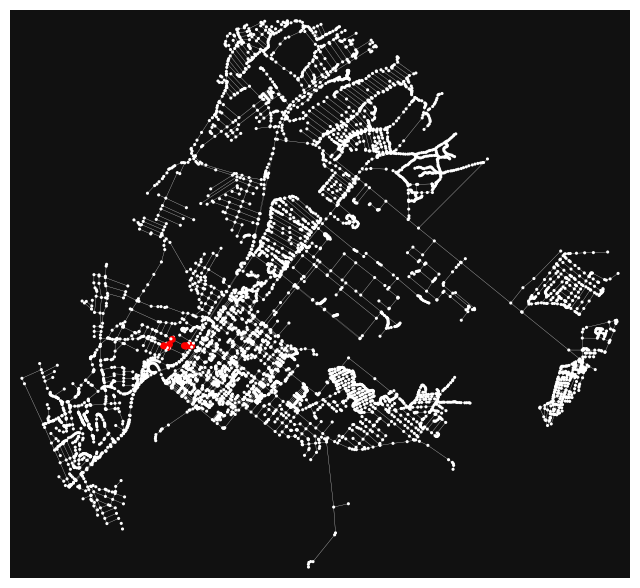

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [12]:
node = 10861549486
best_node, best_val, route = Graphs.get_best_node_drain(G, 
                          path_function=msfpl,
                          metric_function=np.mean,
                          all_nodes=True,
                          start_node=node
                          )
print(best_node, best_val)
nc = ['r' if nd in route else 'w' for nd in G.nodes()]
ns = [25 if nd in route else 5 for nd in G.nodes()]
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

### Расчет для нескольких узлов последовательно

Расчет узла 1526082635
426923837 7.51
Расчет узла 9994288449
426923872 7.65
Расчет узла 6001956585
426923835 7.58
Расчет узла 3981463606
3981463591 7.59
Расчет узла 9086101154
426923846 7.91
Расчет узла 2054468667
1550092538 7.55
Расчет узла 2054468875
1550092538 7.55
Расчет узла 4116020524
6222357764 7.52
Расчет узла 1296599777
426923872 7.65
Расчет узла 2042076795
2034401613 8.25
Расчет узла 10861549486
3119947202 10.13
Расчет узла 2054468665
1550092538 7.55
Расчет узла 2054468312
1550092538 7.55
Расчет узла 2042076774
2034401613 8.25
Расчет узла 2054469087
2034401613 8.25
Расчет узла 4116035751
426923808 7.36
Расчет узла 8089452712
3119947202 10.13
Расчет узла 5574240353
426923872 7.65
Расчет узла 290700364
2034401724 8.45
Расчет узла 5678832322
1577738848 8.81
426923808 7.36


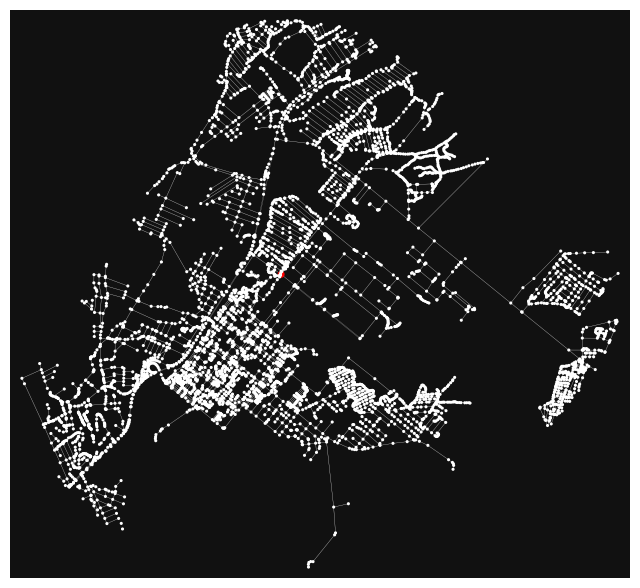

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [21]:
sample_size = 20
start_nodes = random.sample(list(G.nodes()), sample_size)
start_nodes

best_val = 1000
best_node
for node in start_nodes:
    print('Расчет узла', node)
    try:
        cur_node, cur_val = Graphs.get_best_node_drain(G, 
                                path_function=msfpl,
                                metric_function=np.mean,
                                start_node=node
                                )
        print(cur_node, cur_val)
    except ValueError:
        print(f'Узел {node} неприемлем')                               
    if cur_val<best_val:
        best_val = cur_val
        best_node = cur_node

print(best_node, best_val)

nc = ['r' if nd==best_node else 'w' for nd in G.nodes()]
ns = [25 if nd==best_node else 5 for nd in G.nodes()]
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

# Тесты

In [6]:
import numpy as np
import networkx as nx
import osmnx as ox

from genesis.algorithms import Graphs
from genesis.metrics import calc_node_metric, cover_index
from genesis.swiss_knife import msfpl, ssfpl


In [25]:
def create_G():
    '''
        max: 21
        mean: 8.67
        median: 8.0
        ip-10: 66.67
        ip-20: 93.33
    '''
    G = nx.MultiDiGraph()
    G.add_edge(1, 2, key=0, travel_time=3)
    G.add_edge(1, 3, key=0, travel_time=2)
    G.add_edge(1, 4, key=0, travel_time=5)
    G.add_edge(2, 3, key=0, travel_time=2)
    G.add_edge(2, 5, key=0, travel_time=5)
    G.add_edge(2, 6, key=0, travel_time=7)
    G.add_edge(3, 2, key=0, travel_time=3)
    G.add_edge(3, 7, key=0, travel_time=3)
    G.add_edge(3, 8, key=0, travel_time=4)
    G.add_edge(3, 9, key=0, travel_time=5)
    G.add_edge(4, 3, key=0, travel_time=2)
    G.add_edge(4, 8, key=0, travel_time=4)
    G.add_edge(4, 10, key=0, travel_time=12)
    G.add_edge(4, 11, key=0, travel_time=10)
    G.add_edge(5, 8, key=0, travel_time=8)
    G.add_edge(5, 10, key=0, travel_time=8)
    G.add_edge(5, 12, key=0, travel_time=6)
    G.add_edge(5, 13, key=0, travel_time=9)
    G.add_edge(5, 12, key=0, travel_time=8)
    G.add_edge(6, 8, key=0, travel_time=1)
    G.add_edge(6, 9, key=0, travel_time=4)
    G.add_edge(6, 12, key=0, travel_time=4)
    G.add_edge(7, 10, key=0, travel_time=4)
    G.add_edge(7, 11, key=0, travel_time=9)
    G.add_edge(7, 13, key=0, travel_time=7)
    G.add_edge(8, 10, key=0, travel_time=6)
    G.add_edge(8, 13, key=0, travel_time=8)
    G.add_edge(9, 14, key=0, travel_time=10)
    G.add_edge(10, 13, key=0, travel_time=7)
    G.add_edge(10, 14, key=0, travel_time=5)
    G.add_edge(11, 12, key=0, travel_time=7)
    G.add_edge(11, 15, key=0, travel_time=7)
    G.add_edge(12, 13, key=0, travel_time=8)
    return G

G = create_G()
nodes_list=[2,5,8]
best_node, best_val = Graphs.get_best_node_full(G,
                        path_function=msfpl,
                        metric_function=np.mean,
                        possible_nodes=nodes_list,
                        appr_val=0.5
                        )
print(best_node, best_val)

print('метрики для каждого из узлов:')
for node in nodes_list:
    m = calc_node_metric(G,
                     node,
                     path_function=msfpl,
                     metric_function=np.mean,
                     appr_val=0.5,
                     err_val=0)
                    #  err_val='pass')
    print(node, m)

2 8.69
метрики для каждого из узлов:
2 8.69
5 0
8 0


In [14]:
best_node, best_val = Graphs.get_best_node_full(G,
                            path_function=msfpl,
                            metric_function=cover_index(),
                            # appr_val=0,
                            reduce=False
                            )
print(best_node, best_val)

1 66.67


In [11]:
print('метрики для каждого из узлов:')
for node in G.nodes():
    m = calc_node_metric(G,
                     node,
                     path_function=msfpl,
                     metric_function=cover_index(),
                    #  err_val=0)
                     err_val='pass')
    print(node, m)

метрики для каждого из узлов:
1 66.67
2 61.54
3 69.23
4 64.29
5 83.33
6 85.71
7 71.43
8 75.0
9 100.0
10 100.0
11 75.0
12 100.0
13 100.0
14 100.0
15 100.0


In [13]:
print('метрики для каждого из узлов:')
for node in G.nodes():
    m = calc_node_metric(G,
                     node,
                     path_function=msfpl,
                     metric_function=cover_index(),
                     appr_val=0.5,
                     err_val=0)
                    #  err_val='pass')
    print(node, m)

метрики для каждого из узлов:
1 66.67
2 61.54
3 69.23
4 64.29
5 0
6 85.71
7 71.43
8 0
9 0
10 0
11 0
12 0
13 0
14 0
15 0


In [ ]:
print('метрики для каждого из узлов:')
for node in G.nodes():
    m = calc_node_metric(G,
                     node,
                     path_function=msfpl,
                     metric_function=cover_index(),
                     appr_val=1,
                        )
                    # err_val=0)
                    #  err_val='pass')
    print(node, m)

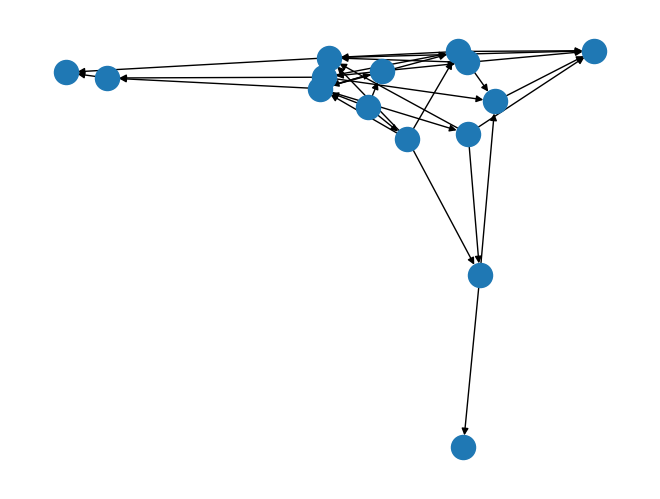

In [18]:
nx.draw(G, pos=nx.spring_layout(G))

In [30]:
pn = None
bn = list(G.nodes())[0]
bn==pn

False

In [10]:
def create_G():
    '''
        max: 21
        mean: 8.67
        median: 8.0
        ip-10: 66.67
        ip-20: 93.33
    '''
    G = nx.MultiDiGraph()
    G.add_edge(1, 2, key=0, travel_time=3)
    G.add_edge(1, 3, key=0, travel_time=2)
    G.add_edge(1, 4, key=0, travel_time=5)
    G.add_edge(2, 3, key=0, travel_time=2)
    G.add_edge(2, 5, key=0, travel_time=5)
    G.add_edge(2, 6, key=0, travel_time=7)
    G.add_edge(3, 2, key=0, travel_time=3)
    G.add_edge(3, 7, key=0, travel_time=3)
    G.add_edge(3, 8, key=0, travel_time=4)
    G.add_edge(3, 9, key=0, travel_time=5)
    G.add_edge(4, 3, key=0, travel_time=2)
    G.add_edge(4, 8, key=0, travel_time=4)
    G.add_edge(4, 10, key=0, travel_time=12)
    G.add_edge(4, 11, key=0, travel_time=10)
    G.add_edge(5, 8, key=0, travel_time=8)
    G.add_edge(5, 10, key=0, travel_time=8)
    G.add_edge(5, 12, key=0, travel_time=6)
    G.add_edge(5, 13, key=0, travel_time=9)
    G.add_edge(5, 12, key=0, travel_time=8)
    G.add_edge(6, 8, key=0, travel_time=1)
    G.add_edge(6, 9, key=0, travel_time=4)
    G.add_edge(6, 12, key=0, travel_time=4)
    G.add_edge(7, 10, key=0, travel_time=4)
    G.add_edge(7, 11, key=0, travel_time=9)
    G.add_edge(7, 13, key=0, travel_time=7)
    G.add_edge(8, 10, key=0, travel_time=6)
    G.add_edge(8, 13, key=0, travel_time=8)
    G.add_edge(9, 14, key=0, travel_time=10)
    G.add_edge(10, 13, key=0, travel_time=7)
    G.add_edge(10, 14, key=0, travel_time=5)
    G.add_edge(11, 12, key=0, travel_time=7)
    G.add_edge(11, 15, key=0, travel_time=7)
    G.add_edge(12, 13, key=0, travel_time=8)
    return G

G = create_G()

In [62]:
for edge in G.in_edges(2):
    print(edge[0])

1
3


In [64]:
for edge in G.out_edges(2):
    print(edge[1])

3
5
6


In [ ]:
G.add_edge(1, 2, key=0, travel_time=3)
G.add_edge(3, 2, key=0, travel_time=3)
G.add_edge(2, 3, key=0, travel_time=2)
G.add_edge(2, 5, key=0, travel_time=5)
G.add_edge(2, 6, key=0, travel_time=7)

In [35]:
G[3]

AdjacencyView({2: {0: {'travel_time': 3}}, 7: {0: {'travel_time': 3}}, 8: {0: {'travel_time': 4}}, 9: {0: {'travel_time': 5}}})